# SMC Assignment Benchmark (Notebook)

Ce notebook remplace `experiments/scripts/run_assignment_benchmark.py` et ajoute une analyse graphique complète :

- comparaison des méthodes d'assignement (`LSA`, `Hilbert`, `Swap`, `smart_*`),
- coût en **temps** et en **nombre de simulations**,
- qualité de posterior via **KL joint** et **KL sigma2**,
- visualisation des **marginales posterior** (`sigma2` et composantes `mu` triées),
- focus dédié aux stratégies **smart accept**.

---

> Conseil: commencer avec une grille réduite pour valider, puis lancer la grille complète.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jax import random

# Project path
PROJECT_ROOT = Path.cwd().resolve().parents[1] if (Path.cwd().name == 'notebooks') else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from permabc.models.Gaussian_with_no_summary_stats import GaussianWithNoSummaryStats
from permabc.algorithms.smc import perm_abc_smc
from permabc.core.kernels import KernelTruncatedRW
from permabc.core.distances import _HAS_NUMBA, _HAS_CGAL, optimal_index_distance
from experiments.scripts.run_performance_comparison import (
    empirical_kl_joint_abc_vs_true,
    empirical_kl_sigma2_abc_vs_true,
)

sns.set_theme(style='whitegrid', context='talk')
print(f'Numba: {_HAS_NUMBA} | CGAL: {_HAS_CGAL}')

Numba: True | CGAL: True


In [16]:
# -----------------------------
# Configuration
# -----------------------------
import numpy as np
SEED = 42
N_PARTICLES = 1000
N_ITER_MAX = np.inf
N_SIM_MAX = np.inf

# Full grid (same spirit as script)
K_VALUES = [2, 3, 5, 10, 25, 50]
N_OBS_VALUES = [2, 5, 10, 25, 100]
ALPHA_VALUES = [0.5, 0.1, 0.01, .001]

METHODS = [
    {'assignment': 'lsa',                'swap': False, 'label': 'LSA'},
    {'assignment': 'lsa',                'swap': True,  'label': 'LSA+Swap'},
    {'assignment': 'hilbert',            'swap': False, 'label': 'Hilbert'},
    {'assignment': 'hilbert',            'swap': True,  'label': 'Hilbert+Swap'},
    {'assignment': None,                 'swap': True,  'label': 'Swap only'},
    {'assignment': 'smart_swap',         'swap': False, 'label': 'Smart Swap'},
    {'assignment': 'smart_hilbert',      'swap': False, 'label': 'Smart Hilbert'},
    {'assignment': 'smart_hilbert_swap', 'swap': False, 'label': 'Smart H+S'},
]

OUT_DIR = PROJECT_ROOT / 'experiments' / 'results' / 'assignment_benchmark_notebook'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUT_DIR / 'benchmark_raw.csv'
POST_PATH = OUT_DIR / 'posterior_samples.csv'

# Optional: reduce for quick dry-run
QUICK_MODE = False
if QUICK_MODE:
    K_VALUES = [3, 10]
    N_OBS_VALUES = [5, 25]
    ALPHA_VALUES = [0.1, 0.01]
    N_PARTICLES = 300
    N_SIM_MAX = 80_000

print('Output:', OUT_DIR)
print('Total runs:', len(K_VALUES) * len(N_OBS_VALUES) * len(ALPHA_VALUES) * len(METHODS))

Output: /Users/antoineluciano/Documents/Recherche/permABC/experiments/results/assignment_benchmark_notebook
Total runs: 960


In [17]:
# -----------------------------
# Helpers
# -----------------------------
def posterior_mse(result, true_loc, true_glob):
    theta = result['Thetas'][-1]
    w = np.asarray(result['Weights'][-1], dtype=float)
    w = w / np.sum(w)

    loc = np.asarray(theta.loc[:, :, 0])
    glob_val = np.asarray(theta.glob[:, 0])

    post_loc = np.average(np.sort(loc, axis=1), weights=w, axis=0)
    post_glob = np.average(glob_val, weights=w)

    true_sorted = np.sort(np.asarray(true_loc).flatten())
    mse_loc = float(np.mean((post_loc - true_sorted) ** 2))
    mse_glob = float((post_glob - float(true_glob)) ** 2)
    return mse_loc, mse_glob


def weighted_quantiles(values, weights, probs=(0.05, 0.5, 0.95)):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values, weights = values[mask], weights[mask]
    if values.size == 0:
        return [np.nan for _ in probs]
    if np.sum(weights) <= 0:
        weights = np.ones_like(values)
    order = np.argsort(values)
    v = values[order]
    w = weights[order]
    cdf = np.cumsum(w) / np.sum(w)
    return [float(v[np.searchsorted(cdf, p, side='left')]) for p in probs]


def collect_posterior_marginals(result, method_label, K, n_obs, alpha, case_tag='default'):
    """Extract weighted samples for sigma2 and selected sorted mu marginals."""
    theta = result['Thetas'][-1]
    w = np.asarray(result['Weights'][-1], dtype=float)
    if np.sum(w) <= 0:
        return []
    w = w / np.sum(w)

    loc = np.asarray(theta.loc[:, :, 0])
    loc_sorted = np.sort(loc, axis=1)
    sigma2 = np.asarray(theta.glob[:, 0])

    # Keep a compact set of marginals even for large K
    idxs = sorted(set([0, max(0, K // 2), K - 1]))
    rows = []
    for i in range(len(sigma2)):
        rows.append({
            'case': case_tag,
            'K': K,
            'n_obs': n_obs,
            'alpha': alpha,
            'method': method_label,
            'param': 'sigma2',
            'param_idx': -1,
            'value': float(sigma2[i]),
            'weight': float(w[i]),
        })
        for j in idxs:
            rows.append({
                'case': case_tag,
                'K': K,
                'n_obs': n_obs,
                'alpha': alpha,
                'method': method_label,
                'param': 'mu_sorted',
                'param_idx': int(j),
                'value': float(loc_sorted[i, j]),
                'weight': float(w[i]),
            })
    return rows


def estimate_epsilon_target_from_perm_vanilla(key, model, y_obs, alpha, n_epsilon=10_000):
    """
    Estimate epsilon_target as the alpha-quantile of permABC-vanilla distances
    computed on n_epsilon prior predictive samples.
    """
    key, k_theta, k_data = random.split(key, 3)
    thetas = model.prior_generator(k_theta, n_epsilon)
    zs = model.data_generator(k_data, thetas)
    dists, _, _, _ = optimal_index_distance(
        model=model,
        zs=zs,
        y_obs=y_obs,
        epsilon=0.0,
        assignment="lsa",
        swap=False,
        verbose=0,
    )
    eps_target = float(np.quantile(np.asarray(dists), alpha))
    return key, eps_target


def run_one(key, model, y_obs, method, alpha, epsilon_target):
    t0 = time.perf_counter()
    res = perm_abc_smc(
        key=key,
        model=model,
        n_particles=N_PARTICLES,
        epsilon_target=float(epsilon_target),
        y_obs=y_obs,
        kernel=KernelTruncatedRW,
        alpha_epsilon=alpha,
        verbose=0,
        N_iteration_max=N_ITER_MAX,
        N_sim_max=N_SIM_MAX,
        assignment=method['assignment'],
        swap=method['swap'],
    )
    elapsed = time.perf_counter() - t0
    return res, elapsed

In [18]:
# -----------------------------
# Main benchmark loop
# -----------------------------
rows = []
posterior_rows = []

key = random.PRNGKey(SEED)

total = len(K_VALUES) * len(N_OBS_VALUES) * len(ALPHA_VALUES) * len(METHODS)
done = 0

t_global = time.perf_counter()

# Choose one reference setting for detailed posterior marginal plots
REF_CASE = {'K': 10, 'n_obs': 10, 'alpha': 0.1}

for K in K_VALUES:
    for n_obs in N_OBS_VALUES:
        model = GaussianWithNoSummaryStats(K=K, n_obs=n_obs)
        key, k1, k2 = random.split(key, 3)
        true_theta = model.prior_generator(k1, 1)
        y_obs = np.asarray(model.data_generator(k2, true_theta))

        true_loc = np.asarray(true_theta.loc[0, :, 0])
        true_glob = float(np.asarray(true_theta.glob[0, 0]))

        for alpha in ALPHA_VALUES:
            key, k_eps = random.split(key)
            _, epsilon_target = estimate_epsilon_target_from_perm_vanilla(
                k_eps, model, y_obs, alpha=alpha, n_epsilon=10_000
            )

            for m in METHODS:
                key, k_run = random.split(key)
                try:
                    res, elapsed = run_one(k_run, model, y_obs, m, alpha, epsilon_target)

                    mse_loc, mse_glob = posterior_mse(res, true_loc, true_glob)
                    kl_joint = empirical_kl_joint_abc_vs_true(
                        model, y_obs,
                        res['Thetas'][-1],
                        weights=res['Weights'][-1],
                        perm=(res['Zs_index'][-1] if 'Zs_index' in res and len(res['Zs_index']) > 0 else None),
                    )
                    kl_sigma2 = empirical_kl_sigma2_abc_vs_true(
                        model, y_obs,
                        res['Thetas'][-1],
                        weights=res['Weights'][-1],
                    )

                    metrics = {
                        'time': float(elapsed),
                        'mse_loc': float(mse_loc),
                        'mse_glob': float(mse_glob),
                        'kl_joint': float(kl_joint) if np.isfinite(kl_joint) else np.nan,
                        'kl_sigma2': float(kl_sigma2) if np.isfinite(kl_sigma2) else np.nan,
                        'n_iters': int(len(res['Eps_values']) - 1),
                        'final_eps': float(res['Eps_values'][-1]),
                        'total_nsim': int(np.sum(res['N_sim'])),
                        'time_per_sim': float(elapsed / max(int(np.sum(res['N_sim'])), 1)),
                        'epsilon_target': float(epsilon_target),
                    }

                    # collect detailed posterior marginals for reference case
                    if K == REF_CASE['K'] and n_obs == REF_CASE['n_obs'] and alpha == REF_CASE['alpha']:
                        posterior_rows.extend(
                            collect_posterior_marginals(
                                res, m['label'], K, n_obs, alpha,
                                case_tag=f"K={K},n={n_obs},a={alpha}"
                            )
                        )

                except Exception as e:
                    print(f"ERROR K={K} n={n_obs} a={alpha} {m['label']}: {e}")
                    metrics = {
                        'time': np.nan,
                        'mse_loc': np.nan,
                        'mse_glob': np.nan,
                        'kl_joint': np.nan,
                        'kl_sigma2': np.nan,
                        'n_iters': np.nan,
                        'final_eps': np.nan,
                        'total_nsim': np.nan,
                        'time_per_sim': np.nan,
                        'epsilon_target': float(epsilon_target),
                    }

                rows.append({
                    'K': K,
                    'n_obs': n_obs,
                    'alpha': alpha,
                    'method': m['label'],
                    **metrics,
                })
                done += 1

            elapsed_total = time.perf_counter() - t_global
            eta = elapsed_total / max(done, 1) * (total - done)
            print(
                f"[{done:4d}/{total}] {done/total*100:5.1f}% "
                f"K={K:2d} n={n_obs:3d} a={alpha} "
                f"elapsed={elapsed_total:.0f}s ETA={eta:.0f}s",
                flush=True,
            )

        pd.DataFrame(rows).to_csv(CSV_PATH, index=False)
        gc.collect()

benchmark_df = pd.DataFrame(rows)
posterior_df = pd.DataFrame(posterior_rows)
benchmark_df.to_csv(CSV_PATH, index=False)
posterior_df.to_csv(POST_PATH, index=False)

print(f"\nDone: {len(benchmark_df)} rows")
print(f"Saved benchmark CSV: {CSV_PATH}")
print(f"Saved posterior CSV: {POST_PATH}")
benchmark_df.head()

[   8/960]   0.8% K= 2 n=  2 a=0.5 elapsed=2s ETA=250s
[  16/960]   1.7% K= 2 n=  2 a=0.1 elapsed=3s ETA=175s
[  24/960]   2.5% K= 2 n=  2 a=0.01 elapsed=4s ETA=144s
[  32/960]   3.3% K= 2 n=  2 a=0.001 elapsed=4s ETA=123s
[  40/960]   4.2% K= 2 n=  5 a=0.5 elapsed=7s ETA=172s
[  48/960]   5.0% K= 2 n=  5 a=0.1 elapsed=8s ETA=156s
[  56/960]   5.8% K= 2 n=  5 a=0.01 elapsed=9s ETA=146s
[  64/960]   6.7% K= 2 n=  5 a=0.001 elapsed=10s ETA=138s
[  72/960]   7.5% K= 2 n= 10 a=0.5 elapsed=11s ETA=136s
[  80/960]   8.3% K= 2 n= 10 a=0.1 elapsed=12s ETA=129s
[  88/960]   9.2% K= 2 n= 10 a=0.01 elapsed=12s ETA=124s
[  96/960]  10.0% K= 2 n= 10 a=0.001 elapsed=13s ETA=119s
[ 104/960]  10.8% K= 2 n= 25 a=0.5 elapsed=14s ETA=119s
[ 112/960]  11.7% K= 2 n= 25 a=0.1 elapsed=15s ETA=115s
[ 120/960]  12.5% K= 2 n= 25 a=0.01 elapsed=16s ETA=112s
[ 128/960]  13.3% K= 2 n= 25 a=0.001 elapsed=17s ETA=108s
[ 136/960]  14.2% K= 2 n=100 a=0.5 elapsed=18s ETA=110s
[ 144/960]  15.0% K= 2 n=100 a=0.1 elapsed=

,K,n_obs,alpha,method,time,mse_loc,mse_glob,kl_joint,kl_sigma2,n_iters,final_eps,total_nsim,time_per_sim,epsilon_target
0,2,2,0.5,LSA,0.129876,4.670138,0.075866,7.975396,7.275314,1,3.840882,4000,0.000032,3.840882
1,2,2,0.5,LSA+Swap,0.072884,4.686067,0.067717,7.921138,7.268188,1,3.840882,4000,0.000018,3.840882
2,2,2,0.5,Hilbert,0.013436,4.310576,0.183184,7.945675,8.202442,2,3.840882,5000,0.000003,3.840882
3,2,2,0.5,Hilbert+Swap,0.127146,4.663289,0.032172,7.857320,7.444680,2,3.840882,5000,0.000025,3.840882
4,2,2,0.5,Swap only,0.016246,4.550673,0.088919,7.916848,7.420046,2,3.840882,5000,0.000003,3.840882


In [19]:
# If you want to reload from disk without rerunning benchmark:
# benchmark_df = pd.read_csv(CSV_PATH)
# posterior_df = pd.read_csv(POST_PATH)

display(benchmark_df.describe(include='all').T[['count']].head())
print('Methods:', sorted(benchmark_df['method'].dropna().unique()))

,count
K,960.0
n_obs,960.0
alpha,960.0
method,960
time,960.0


Methods: ['Hilbert', 'Hilbert+Swap', 'LSA', 'LSA+Swap', 'Smart H+S', 'Smart Hilbert', 'Smart Swap', 'Swap only']


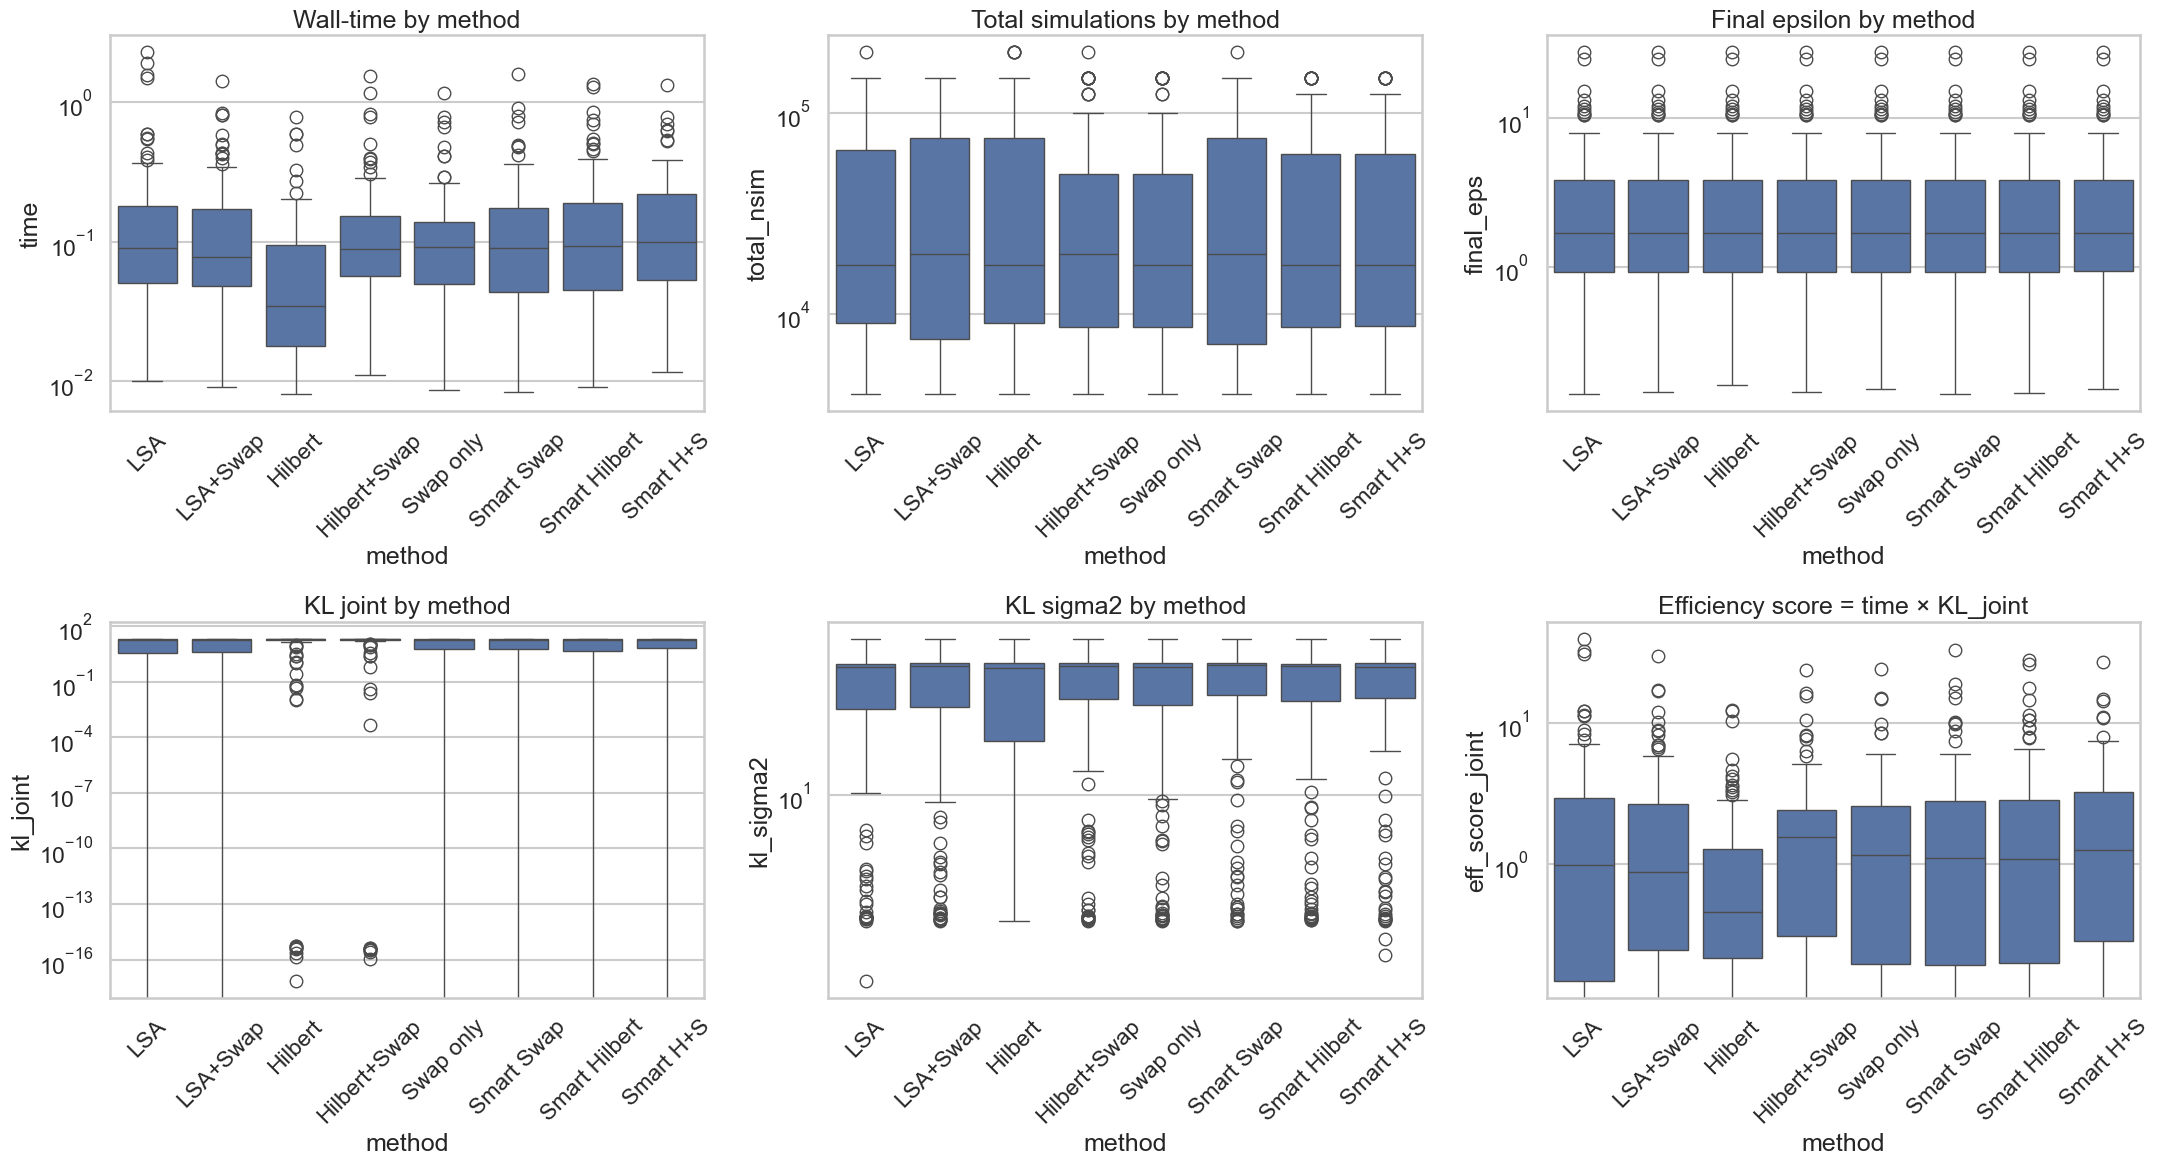

In [20]:
# -----------------------------
# Figure block A: global efficiency/quality
# -----------------------------
df = benchmark_df.copy()
df = df.replace([np.inf, -np.inf], np.nan)

# Relative speedup and relative KL wrt LSA by regime (K, n_obs, alpha)
ref = (
    df[df['method'] == 'LSA'][['K', 'n_obs', 'alpha', 'time', 'total_nsim', 'kl_joint', 'kl_sigma2', 'final_eps']]
    .rename(columns={
        'time': 'time_lsa',
        'total_nsim': 'nsim_lsa',
        'kl_joint': 'kl_joint_lsa',
        'kl_sigma2': 'kl_sigma2_lsa',
        'final_eps': 'eps_lsa',
    })
)

df_rel = df.merge(ref, on=['K', 'n_obs', 'alpha'], how='left')
df_rel['speedup_time'] = df_rel['time_lsa'] / df_rel['time']
df_rel['speedup_nsim'] = df_rel['nsim_lsa'] / df_rel['total_nsim']
df_rel['rel_kl_joint'] = df_rel['kl_joint'] / df_rel['kl_joint_lsa']
df_rel['rel_kl_sigma2'] = df_rel['kl_sigma2'] / df_rel['kl_sigma2_lsa']
df_rel['rel_eps'] = df_rel['final_eps'] / df_rel['eps_lsa']

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

sns.boxplot(data=df_rel, x='method', y='time', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Wall-time by method')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_rel, x='method', y='total_nsim', ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Total simulations by method')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_rel, x='method', y='final_eps', ax=axes[0, 2])
axes[0, 2].set_yscale('log')
axes[0, 2].set_title('Final epsilon by method')
axes[0, 2].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_rel, x='method', y='kl_joint', ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('KL joint by method')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_rel, x='method', y='kl_sigma2', ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('KL sigma2 by method')
axes[1, 1].tick_params(axis='x', rotation=45)

# Efficiency score: lower is better (time * KL_joint)
df_rel['eff_score_joint'] = df_rel['time'] * df_rel['kl_joint']
sns.boxplot(data=df_rel, x='method', y='eff_score_joint', ax=axes[1, 2])
axes[1, 2].set_yscale('log')
axes[1, 2].set_title('Efficiency score = time × KL_joint')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

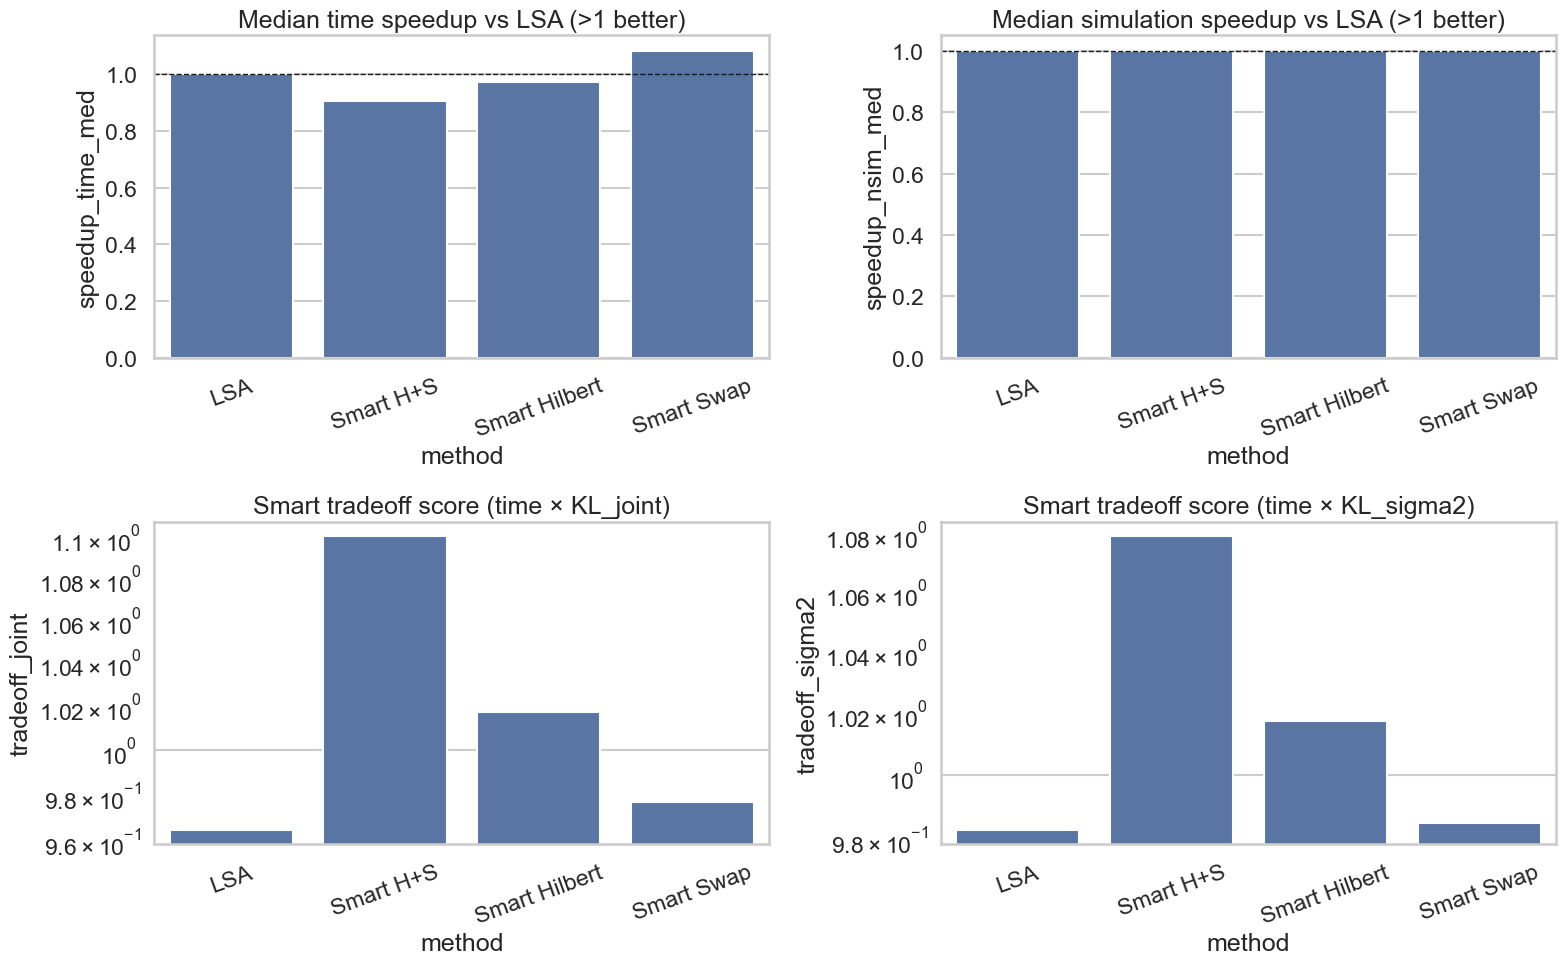

,method,time_med,nsim_med,eps_med,kl_joint_med,kl_sigma2_med,speedup_time_med,speedup_nsim_med,time_med_norm,nsim_med_norm,kl_joint_med_norm,kl_sigma2_med_norm,eps_med_norm,tradeoff_joint,tradeoff_sigma2
0,LSA,0.090280,17500.0,1.712325,17.062393,23.036746,1.000000,1.0,0.984076,1.000000,0.980452,0.998665,1.0,0.964840,0.982763
3,Smart Swap,0.089716,20000.0,1.712325,17.385717,23.228973,1.082080,1.0,0.977933,1.142857,0.999031,1.006998,1.0,0.976986,0.984777
2,Smart Hilbert,0.093201,17500.0,1.712325,17.419429,23.098337,0.973124,1.0,1.015924,1.000000,1.000969,1.001335,1.0,1.016908,1.017280
1,Smart H+S,0.099167,17500.0,1.712325,17.710826,23.026170,0.905342,1.0,1.080952,1.000000,1.017713,0.998207,1.0,1.100099,1.079013


In [21]:
# -----------------------------
# Figure block B: smart accept focus
# -----------------------------
smart_methods = ['LSA', 'Smart Swap', 'Smart Hilbert', 'Smart H+S']
smart_df = df_rel[df_rel['method'].isin(smart_methods)].copy()

agg = (
    smart_df.groupby('method', as_index=False)
    .agg(
        time_med=('time', 'median'),
        nsim_med=('total_nsim', 'median'),
        eps_med=('final_eps', 'median'),
        kl_joint_med=('kl_joint', 'median'),
        kl_sigma2_med=('kl_sigma2', 'median'),
        speedup_time_med=('speedup_time', 'median'),
        speedup_nsim_med=('speedup_nsim', 'median'),
    )
)

# Normalized tradeoff scores (lower better)
for col in ['time_med', 'nsim_med', 'kl_joint_med', 'kl_sigma2_med', 'eps_med']:
    m = np.nanmedian(agg[col])
    agg[col + '_norm'] = agg[col] / m if m and np.isfinite(m) else np.nan
agg['tradeoff_joint'] = agg['time_med_norm'] * agg['kl_joint_med_norm']
agg['tradeoff_sigma2'] = agg['time_med_norm'] * agg['kl_sigma2_med_norm']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=agg, x='method', y='speedup_time_med', ax=axes[0, 0])
axes[0, 0].axhline(1.0, color='k', ls='--', lw=1)
axes[0, 0].set_title('Median time speedup vs LSA (>1 better)')
axes[0, 0].tick_params(axis='x', rotation=20)

sns.barplot(data=agg, x='method', y='speedup_nsim_med', ax=axes[0, 1])
axes[0, 1].axhline(1.0, color='k', ls='--', lw=1)
axes[0, 1].set_title('Median simulation speedup vs LSA (>1 better)')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.barplot(data=agg, x='method', y='tradeoff_joint', ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Smart tradeoff score (time × KL_joint)')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.barplot(data=agg, x='method', y='tradeoff_sigma2', ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Smart tradeoff score (time × KL_sigma2)')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

display(agg.sort_values('tradeoff_joint'))

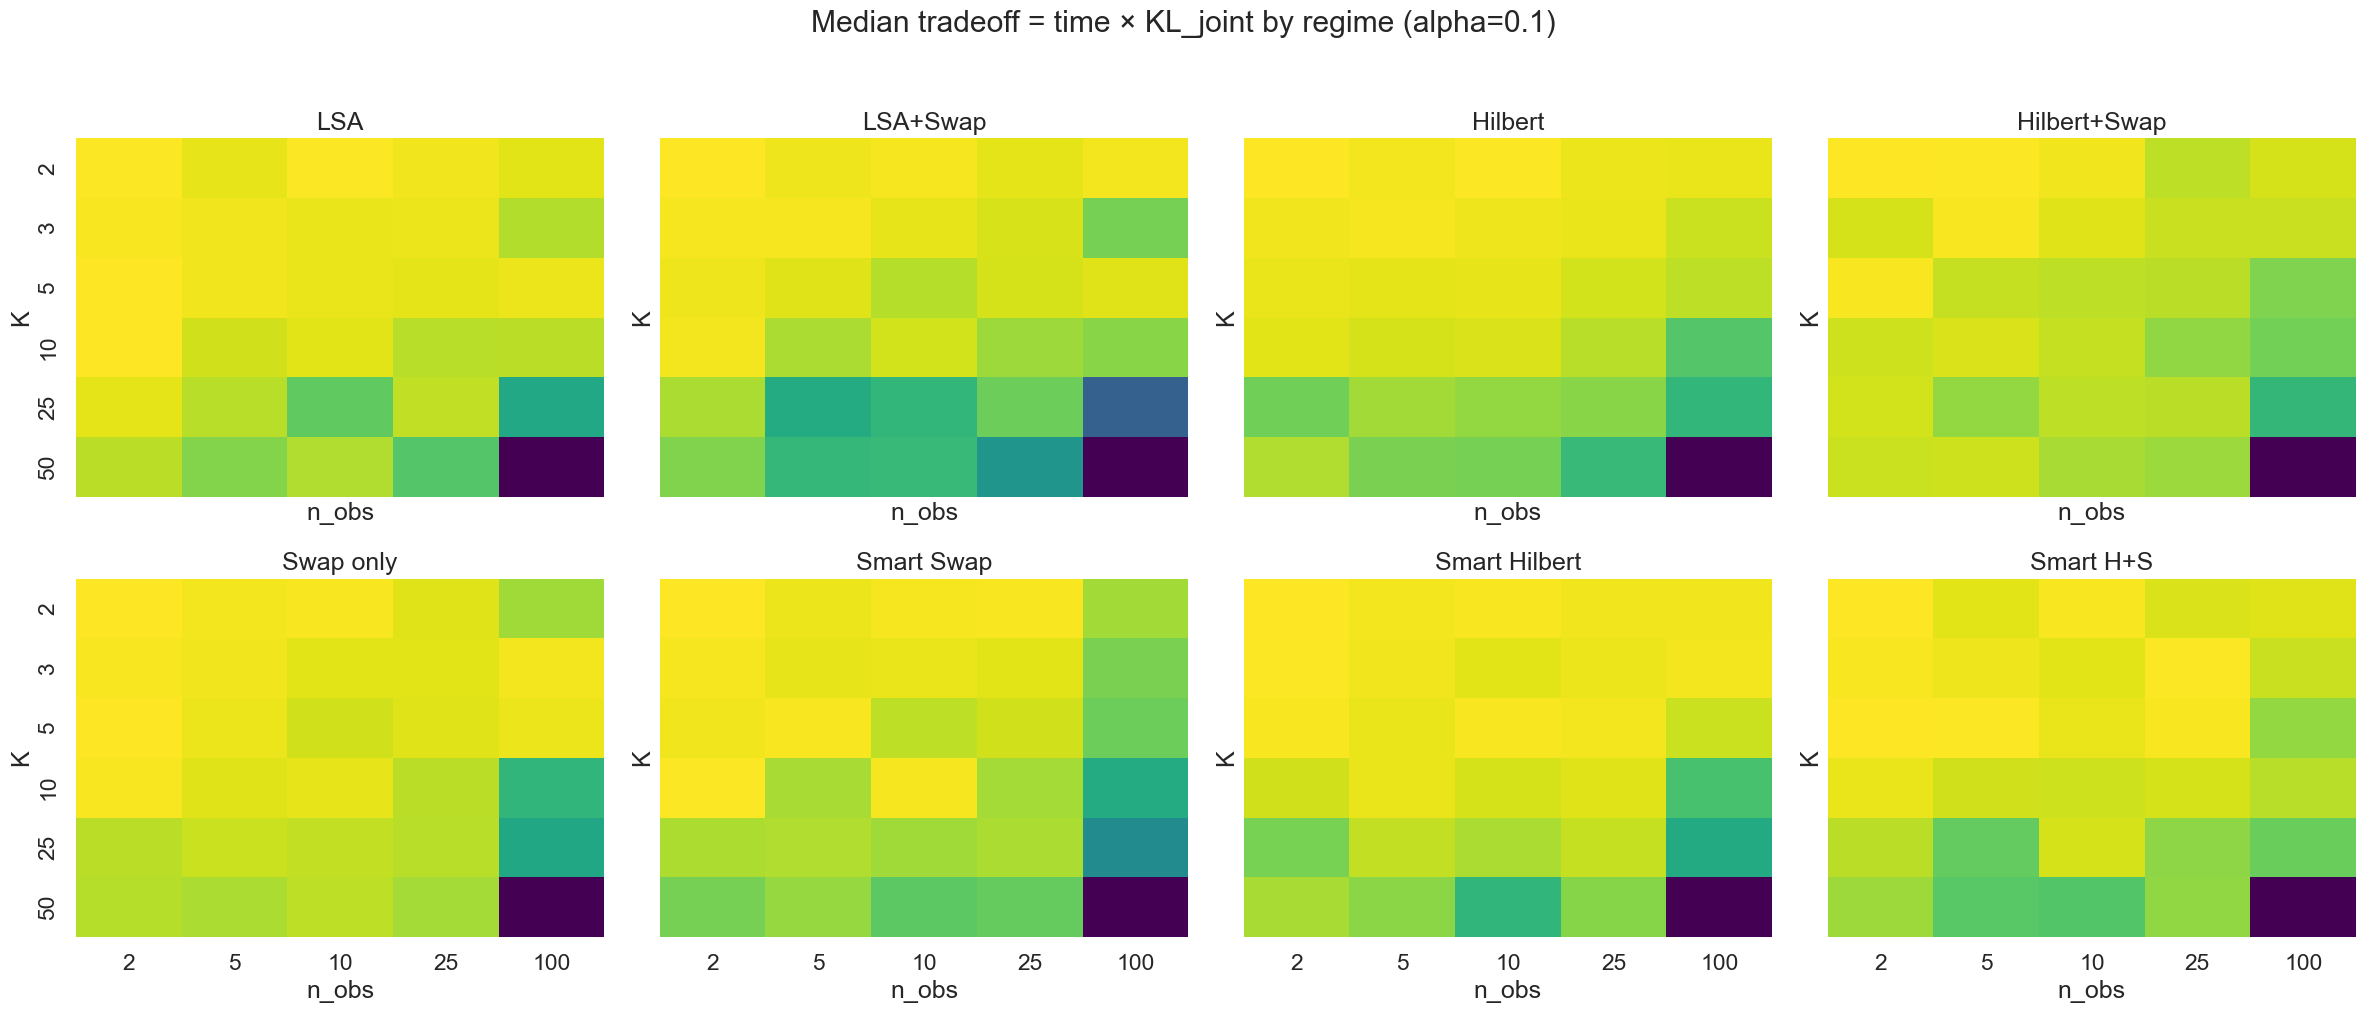

In [22]:
# -----------------------------
# Figure block C: heatmaps by regime
# -----------------------------
# Example at alpha = 0.1 (change as needed)
alpha_view = 0.1
hdf = df_rel[np.isclose(df_rel['alpha'], alpha_view)].copy()

# Metric to display per method
metric = 'tradeoff'
hdf['tradeoff'] = hdf['time'] * hdf['kl_joint']

methods_show = ['LSA', 'LSA+Swap', 'Hilbert', 'Hilbert+Swap', 'Swap only', 'Smart Swap', 'Smart Hilbert', 'Smart H+S']

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
for ax, method in zip(axes.flatten(), methods_show):
    sub = hdf[hdf['method'] == method]
    piv = sub.pivot_table(index='K', columns='n_obs', values=metric, aggfunc='median')
    sns.heatmap(piv, ax=ax, cmap='viridis_r', cbar=False)
    ax.set_title(method)

plt.suptitle(f'Median {metric} = time × KL_joint by regime (alpha={alpha_view})', y=1.02)
plt.tight_layout()
plt.show()

Available case tags: ['K=10,n=10,a=0.1']


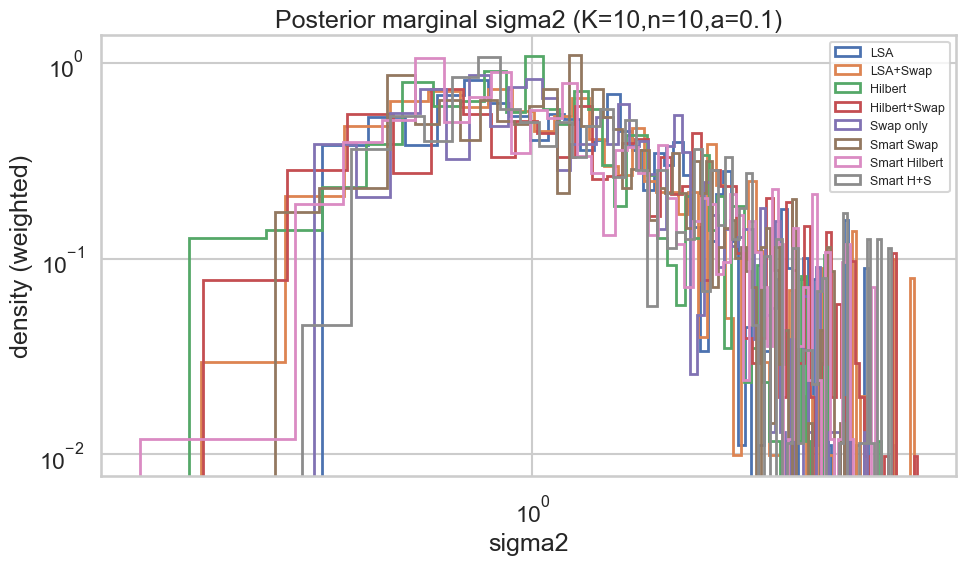

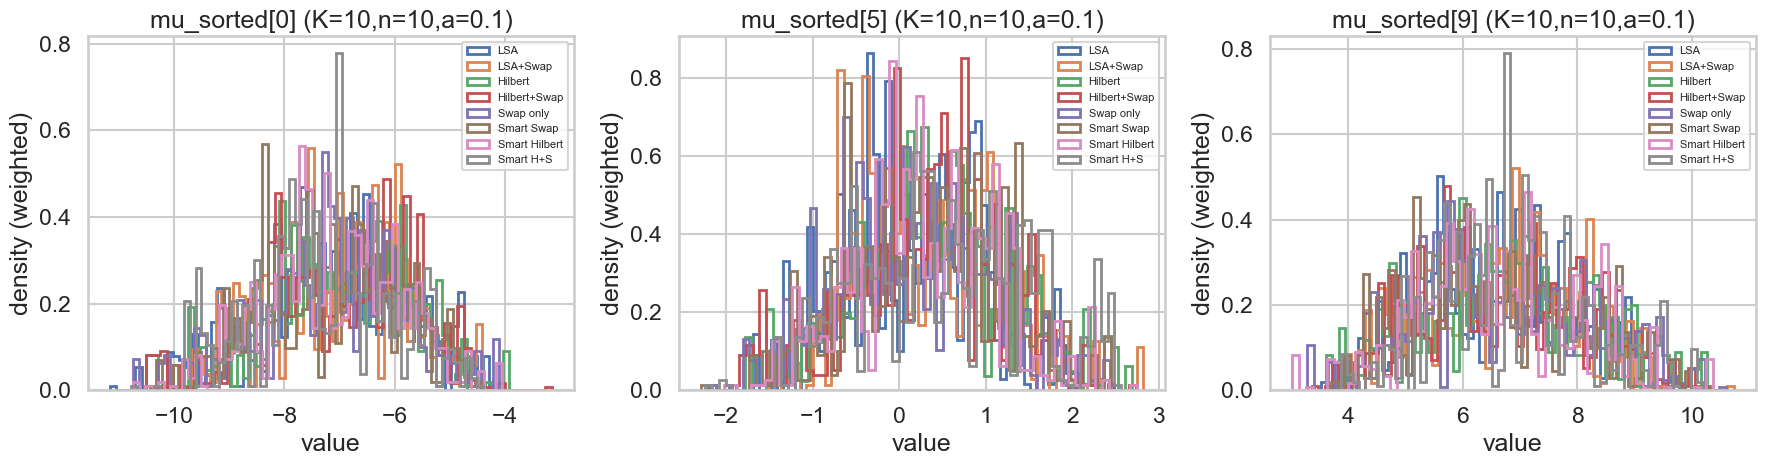

In [23]:
# -----------------------------
# Figure block D: posterior marginals
# -----------------------------
if posterior_df.empty:
    print('posterior_df is empty. Verify REF_CASE exists in your grid.')
else:
    case_vals = posterior_df['case'].unique()
    print('Available case tags:', case_vals)

    case = posterior_df['case'].iloc[0]
    pcase = posterior_df[posterior_df['case'] == case].copy()

    methods_order = ['LSA', 'LSA+Swap', 'Hilbert', 'Hilbert+Swap', 'Swap only', 'Smart Swap', 'Smart Hilbert', 'Smart H+S']

    # Weighted hist for sigma2
    plt.figure(figsize=(10, 6))
    for m in methods_order:
        sub = pcase[(pcase['method'] == m) & (pcase['param'] == 'sigma2')]
        if sub.empty:
            continue
        plt.hist(sub['value'], bins=60, density=True, weights=sub['weight'], histtype='step', linewidth=2, label=m)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Posterior marginal sigma2 ({case})')
    plt.xlabel('sigma2')
    plt.ylabel('density (weighted)')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Selected mu sorted marginals
    mu_df = pcase[pcase['param'] == 'mu_sorted'].copy()
    idx_values = sorted(mu_df['param_idx'].unique())

    fig, axes = plt.subplots(1, len(idx_values), figsize=(6 * len(idx_values), 5), sharey=False)
    if len(idx_values) == 1:
        axes = [axes]

    for ax, idx in zip(axes, idx_values):
        for m in methods_order:
            sub = mu_df[(mu_df['method'] == m) & (mu_df['param_idx'] == idx)]
            if sub.empty:
                continue
            ax.hist(sub['value'], bins=60, density=True, weights=sub['weight'], histtype='step', linewidth=2, label=m)
        ax.set_title(f'mu_sorted[{idx}] ({case})')
        ax.set_xlabel('value')
        ax.set_ylabel('density (weighted)')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [24]:
# -----------------------------
# Optional export of figures
# -----------------------------
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary_table = (
    df_rel.groupby('method', as_index=False)
    .agg(
        time_med=('time', 'median'),
        nsim_med=('total_nsim', 'median'),
        eps_med=('final_eps', 'median'),
        kl_joint_med=('kl_joint', 'median'),
        kl_sigma2_med=('kl_sigma2', 'median'),
        speedup_time_med=('speedup_time', 'median'),
        speedup_nsim_med=('speedup_nsim', 'median'),
    )
    .sort_values('kl_joint_med')
)

summary_csv = OUT_DIR / 'benchmark_summary_medians.csv'
summary_table.to_csv(summary_csv, index=False)
print('Saved:', summary_csv)
display(summary_table.head(20))

Saved: /Users/antoineluciano/Documents/Recherche/permABC/experiments/results/assignment_benchmark_notebook/benchmark_summary_medians.csv


,method,time_med,nsim_med,eps_med,kl_joint_med,kl_sigma2_med,speedup_time_med,speedup_nsim_med
2,LSA,0.090280,17500.0,1.712325,17.062393,23.036746,1.000000,1.0
6,Smart Swap,0.089716,20000.0,1.712325,17.385717,23.228973,1.082080,1.0
5,Smart Hilbert,0.093201,17500.0,1.712325,17.419429,23.098337,0.973124,1.0
3,LSA+Swap,0.076991,20000.0,1.712325,17.699236,23.136007,1.013965,1.0
4,Smart H+S,0.099167,17500.0,1.712325,17.710826,23.026170,0.905342,1.0
7,Swap only,0.091977,17500.0,1.712325,18.130132,22.962633,1.132083,1.0
1,Hilbert+Swap,0.088567,20000.0,1.712325,20.552336,23.179390,1.066278,1.0
0,Hilbert,0.034591,17500.0,1.712325,20.596410,22.868279,2.594579,1.0
